In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/content/student_performance_data.csv')

In [3]:
df.head()

,hours_of_study,hours_of_sleep,Pass/fail_in_an_exam
0,8.99,0.75,Fail
1,22.82,15.27,Pass
2,17.57,7.54,Pass
3,14.37,12.21,Pass
4,3.74,21.78,Pass


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hours_of_study        101 non-null    float64
 1   hours_of_sleep        101 non-null    float64
 2   Pass/fail_in_an_exam  101 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [5]:
missing_values = df.isnull().sum()
print(missing_values)

hours_of_study          0
hours_of_sleep          0
Pass/fail_in_an_exam    0
dtype: int64


In [6]:
df.describe()

,hours_of_study,hours_of_sleep
count,101.000000,101.000000
mean,13.200297,13.450792
std,6.751491,6.652822
min,0.130000,0.590000
25%,8.990000,8.220000
50%,14.000000,14.270000
75%,18.780000,18.550000
max,23.690000,23.660000


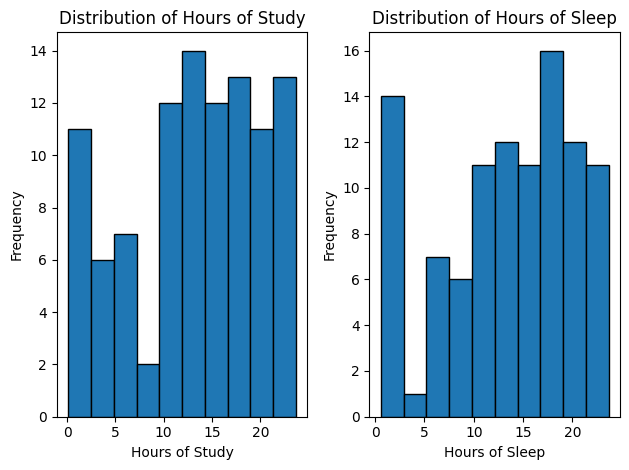

In [7]:
plt.subplot(1, 2, 1)
plt.hist(df['hours_of_study'], bins=10, edgecolor='black')
plt.xlabel('Hours of Study')
plt.ylabel('Frequency')
plt.title('Distribution of Hours of Study')

plt.subplot(1, 2, 2)
plt.hist(df['hours_of_sleep'], bins=10, edgecolor='black')
plt.xlabel('Hours of Sleep')
plt.ylabel('Frequency')
plt.title('Distribution of Hours of Sleep')

plt.tight_layout()
plt.show()

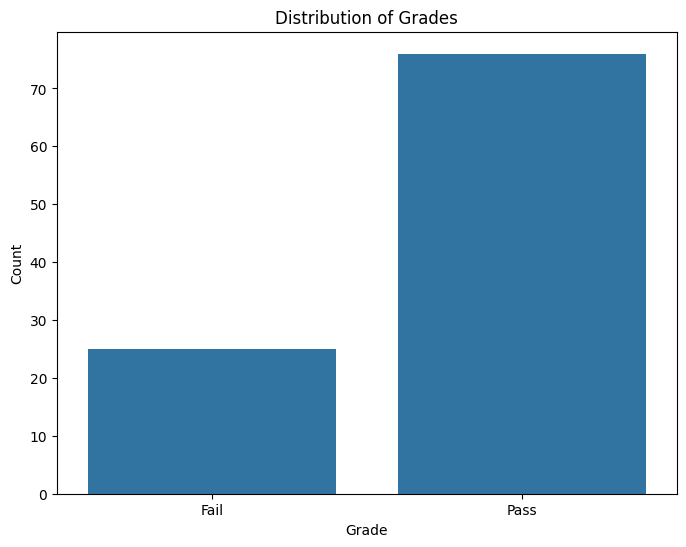

In [10]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.countplot(x='Pass/fail_in_an_exam', data=df)
plt.xlabel('Grade')
plt.ylabel('Count')
plt.title('Distribution of Grades')
plt.show()

,hours_of_study,hours_of_sleep
hours_of_study,1.000000,0.109298
hours_of_sleep,0.109298,1.000000


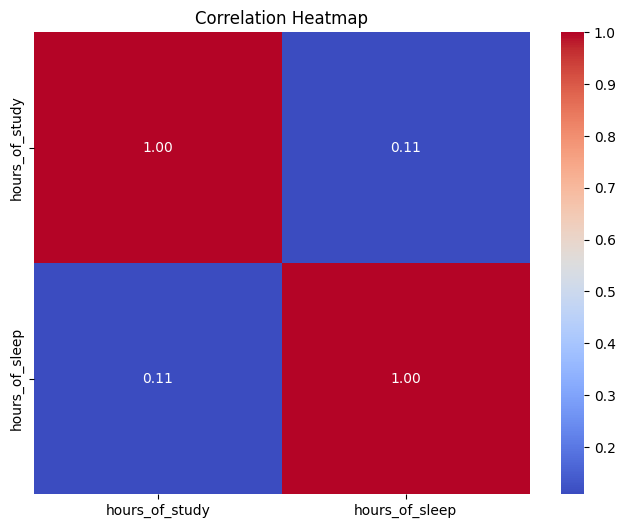

In [11]:
corelation_matrix = df[['hours_of_study', 'hours_of_sleep']].corr()
display(corelation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corelation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [12]:
# df['pass_fail_numerical'] = df['Pass/fail_in_an_exam'].map({'Pass': 1, 'Fail': 0})
df['pass_fail_numerical'] = df['Pass/fail_in_an_exam'].apply(lambda x: 1 if x == 'Pass' else 0)
df.head()

,hours_of_study,hours_of_sleep,Pass/fail_in_an_exam,pass_fail_numerical
0,8.99,0.75,Fail,0
1,22.82,15.27,Pass,1
2,17.57,7.54,Pass,1
3,14.37,12.21,Pass,1
4,3.74,21.78,Pass,1


In [13]:
from numpy._core import numeric
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_columns = ['hours_of_study', 'hours_of_sleep']
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df.head()

,hours_of_study,hours_of_sleep,Pass/fail_in_an_exam,pass_fail_numerical
0,-0.626720,-1.918605,Fail,0
1,1.431933,0.274813,Pass,1
2,0.650449,-0.892895,Pass,1
3,0.174115,-0.187436,Pass,1
4,-1.408205,1.258225,Pass,1


In [14]:
df.describe()

,hours_of_study,hours_of_sleep,pass_fail_numerical
count,1.010000e+02,1.010000e+02,101.000000
mean,3.360211e-16,4.042421e-16,0.752475
std,1.004988e+00,1.004988e+00,0.433727
min,-1.945568e+00,-1.942775e+00,0.000000
25%,-6.267203e-01,-7.901731e-01,1.000000
50%,1.190391e-01,1.237511e-01,1.000000
75%,8.305621e-01,7.702957e-01,1.000000
max,1.561436e+00,1.542222e+00,1.000000


In [15]:
from numpy.matrixlib import test
from sklearn.model_selection import train_test_split

x = df[['hours_of_study', 'hours_of_sleep']]
y = df['pass_fail_numerical']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

print("Training set shape", x_train.shape, y_train.shape)
print("Testing set shape", x_test.shape, y_test.shape)

Training set shape (80, 2) (80,)
Testing set shape (21, 2) (21,)


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Dense(1, activation='sigmoid', input_shape=(x_train.shape[1],)))

model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.5625 - loss: 0.6925 - val_accuracy: 0.6250 - val_loss: 0.6283
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6146 - loss: 0.6783 - val_accuracy: 0.6250 - val_loss: 0.6272
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6250 - loss: 0.6680 - val_accuracy: 0.6250 - val_loss: 0.6261
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5729 - loss: 0.6966 - val_accuracy: 0.6250 - val_loss: 0.6249
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6250 - loss: 0.6685 - val_accuracy: 0.6250 - val_loss: 0.6238
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6458 - loss: 0.6819 - val_accuracy: 0.6250 - val_loss: 0.6227
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6354 - loss: 0.6735 - val_accuracy: 0.6250 - val_loss: 0.6216
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.6250 - loss: 0.6882 - val_accuracy: 0.6250 - val_loss: 0.6205

In [20]:
loss,accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3810 - loss: 0.7106
Test Loss: 0.7106019854545593
Test Accuracy: 0.380952388048172


In [21]:
new_model = Sequential()
new_model.add(Dense(16, activation='sigmoid', input_shape=(x_train.shape[1],))) # Input Layer
new_model.add(Dense(8, activation='sigmoid')) # Hidden Layer
new_model.add(Dense(1, activation='sigmoid')) # Output Layer

new_model.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])

new_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
new_model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2)
new_model.evaluate(x_test, y_test)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.7292 - loss: 0.6191 - val_accuracy: 0.7500 - val_loss: 0.6119
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7604 - loss: 0.6050 - val_accuracy: 0.7500 - val_loss: 0.6082
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7188 - loss: 0.6139 - val_accuracy: 0.7500 - val_loss: 0.6047
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7500 - loss: 0.6011 - val_accuracy: 0.7500 - val_loss: 0.6013
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7083 - loss: 0.6134 - val_accuracy: 0.7500 - val_loss: 0.5981
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7396 - loss: 0.5981 - val_accuracy: 0.7500 - val_loss: 0.5949
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7396 - loss: 0.5957 - val_accuracy: 0.7500 - val_loss: 0.5919
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7500 - loss: 0.5880 - val_accuracy: 0.7500 - val_loss: 0.5889

[0.48485201597213745, 0.8095238208770752]